In [1]:
import numpy as np
import matplotlib.pyplot as plt


def read_latency_data(file_path, ignore):
    with open(file_path, "r") as file:
        latencies = [int(line.strip()) for line in file if line.strip().isdigit()]
    n_ignore = int(len(latencies) * ignore)
    latencies = latencies[n_ignore:]
    return latencies


def plot_cdf(data, title):
    data = np.sort(data)
    cdf = np.arange(1, len(data) + 1) / len(data)

    # plt.figure(figsize=(8, 6))
    # plt.plot(data, cdf, marker=".", linestyle="none")
    # plt.title(title)
    # plt.xlabel("Latency (microseconds)")
    # plt.ylabel("CDF")
    # plt.grid(True)
    # plt.show()

    for pctl in [99]:
        print(f"p{pctl}: {np.percentile(data, pctl).astype(int)}")

In [2]:
rps_values = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250]

for rps in rps_values:
    print(f"rps: {rps}")

    file_path = f"r{rps}-client1.csv"
    plot_cdf(read_latency_data(file_path, ignore=0.2), "Client 1")

    file_path = f"r{rps}-client2.csv"
    plot_cdf(read_latency_data(file_path, ignore=0.2), "Client 2")

    print()

rps: 25
p99: 4357
p99: 5226

rps: 50
p99: 5292
p99: 5591

rps: 75
p99: 6234
p99: 6743

rps: 100
p99: 6587
p99: 7603

rps: 125
p99: 8350
p99: 9477

rps: 150
p99: 10722
p99: 9278

rps: 175
p99: 12035
p99: 13219

rps: 200
p99: 15547
p99: 16459

rps: 225
p99: 21489
p99: 20398

rps: 250
p99: 32376
p99: 34670



{'rps': [50, 100, 150, 200, 250, 300, 350, 400, 450, 500], 'client1': [4.357, 5.292, 6.234, 6.587, 8.35, 10.722, 12.035, 15.547, 21.489, 32.376], 'client2': [5.226, 5.591, 6.743, 7.603, 9.477, 9.278, 13.219, 16.459, 20.398, 34.67], 'diff': [0.8689999999999998, 0.2990000000000004, 0.5090000000000003, 1.016, 1.1270000000000007, -1.443999999999999, 1.1839999999999993, 0.911999999999999, -1.091000000000001, 2.294000000000004]}


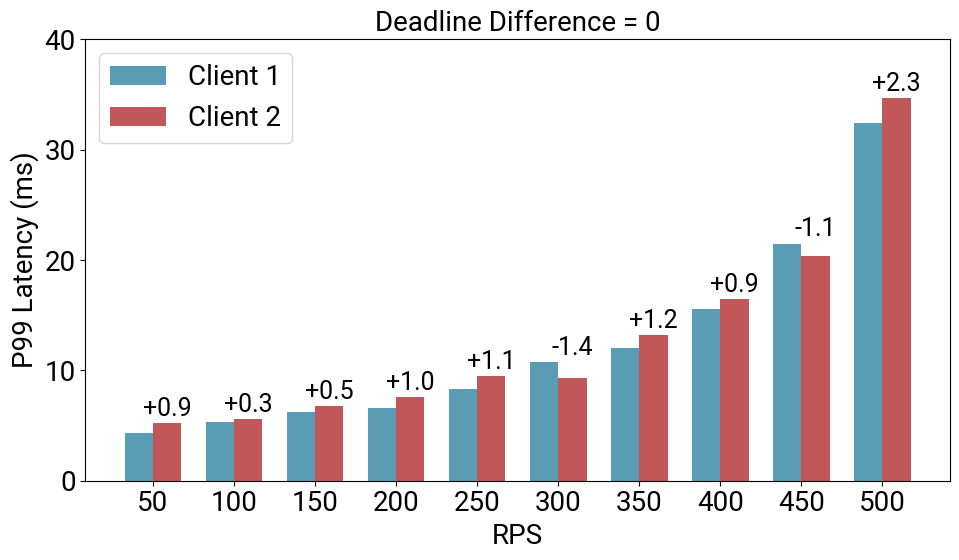

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.family"] = "Roboto"

plt.rcParams.update(
    {
        "font.size": 20,  # Sets the base default font size
        "axes.labelsize": 20,  # Font size for x and y labels
        "axes.titlesize": 20,  # Font size for plot title
        "xtick.labelsize": 20,  # Font size for x-axis tick labels
        "ytick.labelsize": 20,  # Font size for y-axis tick labels
        "legend.fontsize": 20,  # Font size for legend
    }
)

# Sample data
data = {
    "rps": [25, 50, 75, 100, 125, 150, 175, 200, 225, 250],
    "client1": [4357, 5292, 6234, 6587, 8350, 10722, 12035, 15547, 21489, 32376],
    "client2": [5226, 5591, 6743, 7603, 9477, 9278, 13219, 16459, 20398, 34670],
}

for key in ["client1", "client2"]:
    data[key] = [x / 1e3 for x in data[key]]
data["rps"] = [x * 2 for x in data["rps"]]

data["diff"] = []
for i in range(len(data["rps"])):
    data["diff"].append(data["client2"][i] - data["client1"][i])

print(data)

# Setting the positions of the bars on the x-axis
x = np.arange(len(data["rps"]))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(
    x - width / 2,
    data["client1"],
    width,
    label="Client 1",
    color="#599CB4",
)
rects2 = ax.bar(
    x + width / 2,
    data["client2"],
    width,
    label="Client 2",
    color="#C25759",
)

# Annotate the bars with the diff
for i, diff in enumerate(data["diff"]):
    if diff > 0:
        text = f"+{diff:.1f}"
    else:
        text = f"{diff:.1f}"
    ax.text(
        x[i] + width / 2,
        max(data["client1"][i], data["client2"][i]) + 0.2,
        text,
        ha="center",
        va="bottom",
        color="black",
        fontsize=18,
    )

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_title("Deadline Difference = 0")
ax.set_xlabel("RPS")
ax.set_ylabel("P99 Latency (ms)")
ax.set_ylim(0, 40)
ax.set_xticks(x)
ax.set_xticklabels(data["rps"])
ax.legend()

fig.tight_layout()
plt.savefig("ex1.pdf")
plt.show()